In [1]:
# ============================================================================
# CELL 1 - Install dependencies & verify GPU
# ============================================================================
!pip install -q opencv-python-headless scikit-learn matplotlib seaborn

import tensorflow as tf
from tensorflow.keras import mixed_precision

# Mixed precision for speed/memory on T4/V100/A100
mixed_precision.set_global_policy('mixed_float16')

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))
print('Policy     :', mixed_precision.global_policy().name)

# Try to enable XLA jit (skip silently if unavailable)
try:
    tf.config.optimizer.set_jit(True)
    print('XLA jit    : enabled')
except Exception as e:
    print('XLA jit    : disabled ->', e)

# Memory growth (avoid OOM)
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Policy     : mixed_float16
XLA jit    : enabled


In [2]:
# ============================================================================
# CELL 2 - Mount Drive & global configuration
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

import os, math, warnings, json, gc, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, f1_score, average_precision_score,
    precision_recall_curve, matthews_corrcoef, balanced_accuracy_score,
    accuracy_score, precision_score, recall_score
)
from tensorflow.keras import layers, Model, callbacks, optimizers, regularizers
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ----- Paths (THESIS structure) -------------------------------------------
JPEG_BASE  = Path('/content/drive/MyDrive/THESIS/cbis-ddsm/jpeg')
CSV_DIR    = Path('/content/drive/MyDrive/THESIS/cbis-ddsm/csv')
SPLIT_DIR  = Path('/content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split')
SAVE_DIR   = Path('/content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = SPLIT_DIR / 'train'
VAL_DIR   = SPLIT_DIR / 'val'
TEST_DIR  = SPLIT_DIR / 'test'

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert p.exists(), f'Missing split dir: {p}'
    print(f'  OK  {p}')

# ----- Hyper-parameters tuned for MAX performance --------------------------
MODEL_NAME      = 'InceptionV3_MAX'
IMG_SIZE        = 384            # bigger than 299 -> finer mammographic detail
CHANNELS        = 3
BATCH_SIZE      = 24             # smaller because of larger images

PHASE1_EPOCHS   = 15             # head only
PHASE2_EPOCHS   = 30             # top 80 layers
PHASE3_EPOCHS   = 25             # top 150 layers

PHASE1_LR       = 1e-3
PHASE2_LR       = 5e-5
PHASE3_LR       = 5e-6

UNFREEZE_P2     = 80
UNFREEZE_P3     = 150

DROPOUT_RATE    = 0.40
L2_REG          = 5e-5
LABEL_SMOOTH    = 0.05
FOCAL_GAMMA     = 2.0
MIXUP_ALPHA     = 0.20
TTA_STEPS       = 10
RANDOM_SEED     = 42

CUSTOM_HEAD = {'concat_pool', 'gap', 'gmp', 'bn1', 'drop0',
               'fc1', 'bn2', 'act1', 'drop1',
               'fc2', 'bn3', 'act2', 'drop2', 'output'}

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print('=' * 70)
print(f'  Model       : {MODEL_NAME}')
print(f'  Input size  : {IMG_SIZE}x{IMG_SIZE}x{CHANNELS}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Total epochs: {PHASE1_EPOCHS + PHASE2_EPOCHS + PHASE3_EPOCHS}')
print(f'  Save dir    : {SAVE_DIR}')
print('=' * 70)

Mounted at /content/drive
  OK  /content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split/train
  OK  /content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split/val
  OK  /content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split/test
  Model       : InceptionV3_MAX
  Input size  : 384x384x3
  Batch size  : 24
  Total epochs: 70
  Save dir    : /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power


In [3]:
# ============================================================================
# CELL 3 - Dataset inspection + class weights + focal alpha
# ============================================================================
IMG_EXTS = ('.jpg', '.jpeg', '.png')
stats = {}
for split in ['train', 'val', 'test']:
    counts = {}
    for label in ['malignant', 'benign']:
        p = SPLIT_DIR / split / label
        counts[label] = len([f for f in p.iterdir()
                             if f.suffix.lower() in IMG_EXTS]) if p.exists() else 0
    stats[split] = counts

print(f"  {'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7}  Mal%")
print(f"  {'-' * 42}")
for split, cnt in stats.items():
    mal = cnt['malignant']; ben = cnt['benign']; tot = mal + ben
    print(f"  {split:<8} {mal:>10,} {ben:>8,} {tot:>7,}  {mal/tot*100:.1f}%")

n_mal = stats['train']['malignant']
n_ben = stats['train']['benign']
n_tot = n_mal + n_ben
CLASS_WEIGHTS = {0: n_tot / (2 * n_ben), 1: n_tot / (2 * n_mal)}
print(f"\n  Class weights -> benign:{CLASS_WEIGHTS[0]:.4f}  malignant:{CLASS_WEIGHTS[1]:.4f}")

FOCAL_ALPHA = n_ben / n_tot   # weight for the positive (malignant) class
print(f"  Focal alpha (malignant): {FOCAL_ALPHA:.4f}")

  Split     Malignant   Benign   Total  Mal%
  ------------------------------------------
  train         1,004    1,472   2,476  40.5%
  val             231      340     571  40.5%
  test            215      287     502  42.8%

  Class weights -> benign:0.8410  malignant:1.2331
  Focal alpha (malignant): 0.5945


In [4]:
# ============================================================================
# CELL 4 - Strong preprocessing & augmentation (CLAHE, MixUp, Cutout, etc.)
# ============================================================================
AUTOTUNE = tf.data.AUTOTUNE

def apply_clahe(img_np):
    """Contrast-Limited Adaptive Histogram Equalisation in LAB."""
    img_u8 = img_np.astype(np.uint8)
    lab    = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe  = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab_eq = cv2.merge([clahe.apply(l), a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def random_rotate(image):
    """Random 0/90/180/270 deg rotation."""
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    return tf.image.rot90(image, k)

def random_cutout(image, length=80):
    """One rectangular mask placed randomly inside the image (graph-friendly)."""
    h = w = IMG_SIZE
    y = tf.random.uniform([], 0, h, dtype=tf.int32)
    x = tf.random.uniform([], 0, w, dtype=tf.int32)
    y1 = tf.maximum(0, y - length // 2)
    y2 = tf.minimum(h, y + length // 2)
    x1 = tf.maximum(0, x - length // 2)
    x2 = tf.minimum(w, x + length // 2)
    mask = tf.ones((y2 - y1, x2 - x1, 3))
    pad = tf.pad(mask,
                 [[y1, h - y2], [x1, w - x2], [0, 0]],
                 constant_values=0.0)
    return image * (1.0 - pad)

def preprocess_train(image_path, label):
    raw   = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_SIZE + 32, IMG_SIZE + 32])
    image = tf.cast(image, tf.uint8)
    image = tf.py_function(lambda x: apply_clahe(x.numpy()), [image], tf.uint8)
    image.set_shape([IMG_SIZE + 32, IMG_SIZE + 32, 3])
    image = tf.cast(image, tf.float32)

    # Geometric aug
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = random_rotate(image)

    # Photometric aug (raw 0-255 scale)
    image = tf.image.random_brightness(image, max_delta=25.0)
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.clip_by_value(image, 0.0, 255.0)

    image = preprocess_input(image)   # scales to [-1, 1]

    # Cutout, 50% of the time
    image = tf.cond(tf.random.uniform([]) < 0.5,
                    lambda: random_cutout(image, length=80),
                    lambda: image)

    # Light noise
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.015)
    image = tf.clip_by_value(image + noise, -2.0, 2.0)

    return image, tf.cast(label, tf.float32)

def preprocess_val(image_path, label):
    raw   = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.uint8)
    image = tf.py_function(lambda x: apply_clahe(x.numpy()), [image], tf.uint8)
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

def preprocess_tta(image_path, label):
    """Mild augmentation for test-time averaging."""
    raw   = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_SIZE + 16, IMG_SIZE + 16])
    image = tf.cast(image, tf.uint8)
    image = tf.py_function(lambda x: apply_clahe(x.numpy()), [image], tf.uint8)
    image.set_shape([IMG_SIZE + 16, IMG_SIZE + 16, 3])
    image = tf.cast(image, tf.float32)
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = random_rotate(image)
    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

# ----- MixUp (operates on a batch already produced by tf.data) ------------
def sample_beta(alpha):
    """Beta(alpha,alpha) sample via two Gamma RVs (no deprecated APIs)."""
    g1 = tf.random.gamma([], alpha)
    g2 = tf.random.gamma([], alpha)
    return g1 / (g1 + g2)

def mixup(images, labels, alpha=MIXUP_ALPHA):
    batch_size = tf.shape(images)[0]
    lam = sample_beta(alpha)
    lam = tf.maximum(lam, 1.0 - lam)   # bias toward keeping the ground-truth label
    idx = tf.random.shuffle(tf.range(batch_size))
    images_b = tf.gather(images, idx)
    labels_b = tf.gather(labels, idx)
    images_mix = lam * images + (1.0 - lam) * images_b
    labels_mix = lam * labels + (1.0 - lam) * labels_b
    return images_mix, labels_mix

In [5]:
# ============================================================================
# CELL 5 - tf.data pipelines
# ============================================================================
def collect(split_path):
    paths, labels = [], []
    for name, val in [('malignant', 1), ('benign', 0)]:
        folder = split_path / name
        if folder.exists():
            for f in sorted(folder.iterdir()):
                if f.suffix.lower() in IMG_EXTS:
                    paths.append(str(f))
                    labels.append(val)
    return paths, labels

def make_ds(split_path, fn, shuffle=False, mixup_on=False):
    paths, labels = collect(split_path)
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32)))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    if mixup_on:
        ds = ds.map(lambda x, y: mixup(x, y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE), len(paths), paths, labels

# Phase 1 uses MixUp, phases 2/3 turn it off so the model focuses on real patterns.
train_ds_mix,   n_train, train_paths, train_labels = make_ds(TRAIN_DIR, preprocess_train, True, True)
train_ds_clean, _,       _,           _            = make_ds(TRAIN_DIR, preprocess_train, True, False)
val_ds,         n_val,   val_paths,   val_labels   = make_ds(VAL_DIR,   preprocess_val)
test_ds,        n_test,  test_paths,  test_labels  = make_ds(TEST_DIR,  preprocess_val)

steps_per_epoch = math.ceil(n_train / BATCH_SIZE)
print(f'  Train:{n_train:,}  Val:{n_val:,}  Test:{n_test:,}  Steps/ep:{steps_per_epoch}')

  Train:2,476  Val:571  Test:502  Steps/ep:104


In [6]:
# ============================================================================
# CELL 6 - Build InceptionV3 + powerful head
# ============================================================================
def build_model():
    base = InceptionV3(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    base.trainable = False

    x = base.output
    gap = layers.GlobalAveragePooling2D(name='gap')(x)
    gmp = layers.GlobalMaxPooling2D(name='gmp')(x)
    x   = layers.Concatenate(name='concat_pool')([gap, gmp])

    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(0.30, name='drop0')(x)

    x = layers.Dense(1024, kernel_regularizer=regularizers.l2(L2_REG), name='fc1')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('swish', name='act1')(x)
    x = layers.Dropout(DROPOUT_RATE, name='drop1')(x)

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2_REG), name='fc2')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('swish', name='act2')(x)
    x = layers.Dropout(0.30, name='drop2')(x)

    out = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    return Model(base.input, out, name='InceptionV3_MAX_POWER'), base

model, base = build_model()
print(f'  Total params     : {model.count_params():,}')
print(f'  Trainable params : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Total params     : 26,545,953
  Trainable params : 4,731,905


In [7]:
# ============================================================================
# CELL 7 - Loss (focal + label smoothing) + LR schedule + SWA callback
# ============================================================================
def focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTH):
    """Binary focal loss with optional label smoothing."""
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        if label_smoothing > 0:
            y_true = y_true * (1.0 - label_smoothing) + 0.5 * label_smoothing
        eps    = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        bce    = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal  = tf.pow(1.0 - p_t, gamma)
        if alpha is not None:
            alpha_t = y_true * alpha + (1 - y_true) * (1.0 - alpha)
            focal   = focal * alpha_t
        return tf.reduce_mean(focal * bce)
    return loss_fn

def cosine_warmup_schedule(init_lr, total_epochs, steps_ep,
                           warmup_ep=2, min_lr_ratio=1e-3):
    cosine = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=init_lr,
        first_decay_steps=max((total_epochs - warmup_ep) * steps_ep // 3, 1),
        t_mul=2.0, m_mul=0.85, alpha=min_lr_ratio)
    warmup_steps = warmup_ep * steps_ep

    class Schedule(tf.keras.optimizers.schedules.LearningRateSchedule):
        def __call__(self, step):
            step = tf.cast(step, tf.float32)
            return tf.where(step < warmup_steps,
                            init_lr * (step / max(warmup_steps, 1)),
                            cosine(tf.maximum(step - warmup_steps, 0)))
        def get_config(self): return {}
    return Schedule()

METRICS = [
    'accuracy',
    tf.keras.metrics.AUC(name='auc',    curve='ROC'),
    tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
]

class SWACallback(tf.keras.callbacks.Callback):
    """Stochastic Weight Averaging of the top-N checkpoints by `monitor`."""
    def __init__(self, monitor='val_auc', mode='max', n_models=5, save_path=None):
        super().__init__()
        self.monitor   = monitor
        self.mode      = mode
        self.n_models  = n_models
        self.save_path = save_path
        self.history   = []

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            return
        score = logs.get(self.monitor)
        if score is None:
            return
        snap = [w.numpy().copy() for w in self.model.weights]
        self.history.append((float(score), snap))
        self.history.sort(key=lambda x: x[0], reverse=(self.mode == 'max'))
        self.history = self.history[:self.n_models]

    def apply_swa(self):
        if not self.history:
            print('  SWA: no snapshots, skipping.')
            return
        n = len(self.history)
        avg = [np.zeros_like(w) for w in self.history[0][1]]
        for _, snap in self.history:
            for i, w in enumerate(snap):
                avg[i] += w / n
        for w_var, w_avg in zip(self.model.weights, avg):
            w_var.assign(w_avg)
        print(f'  SWA applied (averaged top {n} checkpoints).')
        if self.save_path is not None:
            self.model.save_weights(self.save_path)

In [8]:
# ============================================================================
# CELL 8 - PHASE 1: Train head only (backbone frozen) - MixUp ON
# ============================================================================
print('\n' + '='*70)
print('  PHASE 1 - Head training (backbone frozen, MixUp ON)')
print('='*70)

phase1_ckpt = str(SAVE_DIR / 'phase1_best.weights.h5')

model.compile(
    optimizer=optimizers.Adam(
        cosine_warmup_schedule(PHASE1_LR, PHASE1_EPOCHS, steps_per_epoch, warmup_ep=2)),
    loss=focal_loss(),
    metrics=METRICS,
)

swa_p1 = SWACallback(monitor='val_auc', mode='max', n_models=3,
                     save_path=str(SAVE_DIR / 'phase1_swa.weights.h5'))

history_p1 = model.fit(
    train_ds_mix, epochs=PHASE1_EPOCHS, validation_data=val_ds,
    class_weight=CLASS_WEIGHTS, verbose=1,
    callbacks=[
        callbacks.ModelCheckpoint(phase1_ckpt, monitor='val_auc', mode='max',
                                  save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor='val_auc', patience=8, mode='max',
                                restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / 'phase1_history.csv')),
        swa_p1,
    ])

best_p1 = max(history_p1.history['val_auc'])
print(f'  PHASE 1 done -> best val_AUC = {best_p1:.4f}')
swa_p1.apply_swa()
model.load_weights(phase1_ckpt)   # use the best single checkpoint going into phase 2
gc.collect()


  PHASE 1 - Head training (backbone frozen, MixUp ON)
Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.3171 - auc: 0.5839 - loss: 0.2465 - pr_auc: 0.6889 - precision: 0.6856 - recall: 0.4766
Epoch 1: val_auc improved from None to 0.64886, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/phase1_best.weights.h5
104/104 ━━━━━━━━━━━━━━━━━━━━ 131s 912ms/step - accuracy: 0.3231 - auc: 0.5815 - loss: 0.2501 - pr_auc: 0.6921 - precision: 0.6946 - recall: 0.4997 - val_accuracy: 0.6235 - val_auc: 0.6489 - val_loss: 0.2134 - val_pr_auc: 0.5510 - val_precision: 0.5345 - val_recall: 0.5368
Epoch 2/15
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.2837 - auc: 0.5418 - loss: 0.2514 - pr_auc: 0.6709 - precision: 0.6672 - recall: 0.5190
Epoch 2: val_auc did not improve from 0.64886
104/104 ━━━━━━━━━━━

1124

In [9]:
# ============================================================================
# CELL 9 - PHASE 2: Fine-tune top 80 layers (no MixUp)
# ============================================================================
print('\n' + '='*70)
print(f'  PHASE 2 - Fine-tune top {UNFREEZE_P2} layers')
print('='*70)

phase2_ckpt = str(SAVE_DIR / 'phase2_best.weights.h5')

backbone_layers = [l for l in model.layers if l.name not in CUSTOM_HEAD]
for l in backbone_layers:
    l.trainable = False
unfrozen = 0
for l in backbone_layers[-UNFREEZE_P2:]:
    if not isinstance(l, layers.BatchNormalization):
        l.trainable = True
        unfrozen += 1
print(f'  Unfrozen (non-BN): {unfrozen}')

model.compile(
    optimizer=optimizers.Adam(
        cosine_warmup_schedule(PHASE2_LR, PHASE2_EPOCHS, steps_per_epoch, warmup_ep=3)),
    loss=focal_loss(),
    metrics=METRICS,
)

swa_p2 = SWACallback(monitor='val_auc', mode='max', n_models=5,
                     save_path=str(SAVE_DIR / 'phase2_swa.weights.h5'))

history_p2 = model.fit(
    train_ds_clean, epochs=PHASE2_EPOCHS, validation_data=val_ds,
    class_weight=CLASS_WEIGHTS, verbose=1,
    callbacks=[
        callbacks.ModelCheckpoint(phase2_ckpt, monitor='val_auc', mode='max',
                                  save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor='val_auc', patience=10, mode='max',
                                restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / 'phase2_history.csv')),
        swa_p2,
    ])

best_p2 = max(history_p2.history['val_auc'])
print(f'  PHASE 2 done -> best val_AUC = {best_p2:.4f}')
swa_p2.apply_swa()
model.load_weights(phase2_ckpt)
gc.collect()


  PHASE 2 - Fine-tune top 80 layers
  Unfrozen (non-BN): 57
Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.6580 - auc: 0.7246 - loss: 0.1943 - pr_auc: 0.6141 - precision: 0.5667 - recall: 0.6638
Epoch 1: val_auc improved from None to 0.74806, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/phase2_best.weights.h5
104/104 ━━━━━━━━━━━━━━━━━━━━ 113s 644ms/step - accuracy: 0.6365 - auc: 0.7054 - loss: 0.1970 - pr_auc: 0.5983 - precision: 0.5526 - recall: 0.6340 - val_accuracy: 0.6515 - val_auc: 0.7481 - val_loss: 0.1890 - val_pr_auc: 0.6430 - val_precision: 0.5491 - val_recall: 0.7749
Epoch 2/30
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6419 - auc: 0.7005 - loss: 0.1952 - pr_auc: 0.6046 - precision: 0.5525 - recall: 0.6483
Epoch 2: val_auc did not improve from 0.74806
104/104 ━━━━━

1184

In [10]:
# ============================================================================
# CELL 10 - PHASE 3: Fine-tune top 150 layers with very low LR
# ============================================================================
print('\n' + '='*70)
print(f'  PHASE 3 - Fine-tune top {UNFREEZE_P3} layers (deep tuning)')
print('='*70)

phase3_ckpt = str(SAVE_DIR / 'phase3_best.weights.h5')

for l in backbone_layers:
    l.trainable = False
unfrozen = 0
for l in backbone_layers[-UNFREEZE_P3:]:
    if not isinstance(l, layers.BatchNormalization):
        l.trainable = True
        unfrozen += 1
print(f'  Unfrozen (non-BN): {unfrozen}')

model.compile(
    optimizer=optimizers.Adam(
        cosine_warmup_schedule(PHASE3_LR, PHASE3_EPOCHS, steps_per_epoch, warmup_ep=2,
                               min_lr_ratio=1e-4)),
    loss=focal_loss(),
    metrics=METRICS,
)

swa_p3 = SWACallback(monitor='val_auc', mode='max', n_models=5,
                     save_path=str(SAVE_DIR / 'phase3_swa.weights.h5'))

history_p3 = model.fit(
    train_ds_clean, epochs=PHASE3_EPOCHS, validation_data=val_ds,
    class_weight=CLASS_WEIGHTS, verbose=1,
    callbacks=[
        callbacks.ModelCheckpoint(phase3_ckpt, monitor='val_auc', mode='max',
                                  save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor='val_auc', patience=12, mode='max',
                                restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / 'phase3_history.csv')),
        swa_p3,
    ])

best_p3 = max(history_p3.history['val_auc'])
print(f'  PHASE 3 done -> best val_AUC = {best_p3:.4f}')
swa_p3.apply_swa()
model.save(str(SAVE_DIR / 'inceptionv3_max_power_final.keras'))
model.save_weights(str(SAVE_DIR / 'final_swa.weights.h5'))
print('  Final SWA model saved.')


  PHASE 3 - Fine-tune top 150 layers (deep tuning)
  Unfrozen (non-BN): 106
Epoch 1/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.7652 - auc: 0.8299 - loss: 0.1592 - pr_auc: 0.7689 - precision: 0.6429 - recall: 0.7864
Epoch 1: val_auc improved from None to 0.79558, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/phase3_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/phase3_best.weights.h5
104/104 ━━━━━━━━━━━━━━━━━━━━ 96s 515ms/step - accuracy: 0.7508 - auc: 0.8326 - loss: 0.1630 - pr_auc: 0.7761 - precision: 0.6502 - recall: 0.7870 - val_accuracy: 0.7110 - val_auc: 0.7956 - val_loss: 0.1708 - val_pr_auc: 0.7273 - val_precision: 0.6115 - val_recall: 0.7835
Epoch 2/25
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7701 - auc: 0.8644 - loss: 0.1597 - pr_auc: 0.8126 - precision: 0.6776 - recall: 0.8258
Epoch 2: val_auc did not improve from 0.7955

In [11]:
# ============================================================================
# CELL 11 - Pick best checkpoint (single + ensemble) and run TTA on test set
# ============================================================================
print('\n' + '='*70)
print('  Choosing best checkpoint by val_AUC + running TTA')
print('='*70)

candidates = {
    'phase1_best': str(SAVE_DIR / 'phase1_best.weights.h5'),
    'phase2_best': str(SAVE_DIR / 'phase2_best.weights.h5'),
    'phase3_best': str(SAVE_DIR / 'phase3_best.weights.h5'),
    'phase2_swa' : str(SAVE_DIR / 'phase2_swa.weights.h5'),
    'phase3_swa' : str(SAVE_DIR / 'phase3_swa.weights.h5'),
}

all_val_probs = {}
best_name, best_score = None, -1
for name, path in candidates.items():
    if not os.path.exists(path):
        continue
    model.load_weights(path)
    probs = model.predict(val_ds, verbose=0).flatten()
    auc = roc_auc_score(val_labels, probs)
    all_val_probs[name] = probs
    print(f'  {name:<13} val_AUC = {auc:.4f}')
    if auc > best_score:
        best_score = auc
        best_name  = name

print(f'\n  -> best single checkpoint: {best_name} (val_AUC={best_score:.4f})')

# Top-3 ensemble (arithmetic mean of probabilities)
ranked = sorted(all_val_probs.items(),
                key=lambda kv: roc_auc_score(val_labels, kv[1]), reverse=True)
top3   = ranked[:3]
ens_val = np.mean([p for _, p in top3], axis=0)
ens_auc = roc_auc_score(val_labels, ens_val)
print(f'  Ensemble of top-3 ({[n for n,_ in top3]}) val_AUC = {ens_auc:.4f}')

USE_ENSEMBLE = ens_auc > best_score
if USE_ENSEMBLE:
    print('  -> ensemble beats single best, using ensemble.')
else:
    print('  -> single best wins, using single checkpoint.')
    model.load_weights(candidates[best_name])

def make_tta_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32)))
    return (ds.map(preprocess_tta, num_parallel_calls=AUTOTUNE)
              .batch(BATCH_SIZE).prefetch(AUTOTUNE))

def make_clean_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32)))
    return (ds.map(preprocess_val, num_parallel_calls=AUTOTUNE)
              .batch(BATCH_SIZE).prefetch(AUTOTUNE))

def tta_predict(weight_files, paths, labels, n_tta=TTA_STEPS):
    """Average predictions across `weight_files` x (1 deterministic + n_tta augmented)."""
    runs_per_model = []
    for wpath in weight_files:
        model.load_weights(wpath)
        # 1 deterministic prediction
        det = model.predict(make_clean_ds(paths, labels), verbose=0).flatten()
        runs = [det]
        for _ in range(n_tta):
            runs.append(model.predict(make_tta_ds(paths, labels), verbose=0).flatten())
        runs_per_model.append(np.mean(runs, axis=0))
    return np.mean(runs_per_model, axis=0)

if USE_ENSEMBLE:
    weight_files = [candidates[n] for n, _ in top3]
    print(f'\n  Running TTA over ensemble ({len(weight_files)} models x {TTA_STEPS+1} crops)...')
else:
    weight_files = [candidates[best_name]]
    print(f'\n  Running TTA on {best_name} ({TTA_STEPS+1} crops)...')

y_prob_test = tta_predict(weight_files, test_paths, test_labels, n_tta=TTA_STEPS)
y_prob_val  = tta_predict(weight_files, val_paths,  val_labels,  n_tta=max(5, TTA_STEPS // 2))
print(f'  TTA done. test probs shape: {y_prob_test.shape}')


  Choosing best checkpoint by val_AUC + running TTA
  phase1_best   val_AUC = 0.7457
  phase2_best   val_AUC = 0.7917
  phase3_best   val_AUC = 0.7955
  phase2_swa    val_AUC = 0.7952
  phase3_swa    val_AUC = 0.7962

  -> best single checkpoint: phase3_swa (val_AUC=0.7962)
  Ensemble of top-3 (['phase3_swa', 'phase3_best', 'phase2_swa']) val_AUC = 0.7980
  -> ensemble beats single best, using ensemble.

  Running TTA over ensemble (3 models x 11 crops)...
  TTA done. test probs shape: (502,)



  Threshold search on VAL set
  thr (best balanced_accuracy) = 0.4950
  thr (best F1)                = 0.4850
  thr (best MCC)               = 0.4950
  thr (Youden from ROC)        = 0.4974

  -> chosen OPT_THR = 0.4958  (mean of bal_acc / MCC / Youden-ROC)


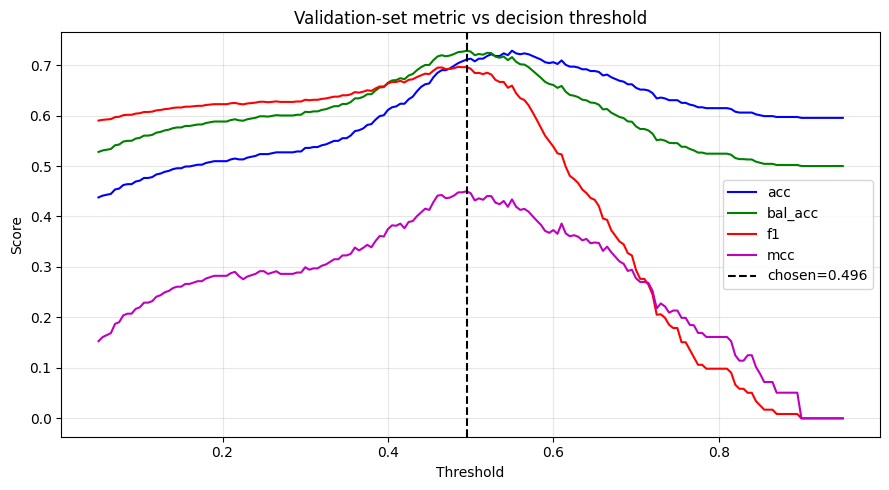

In [12]:
# ============================================================================
# CELL 12 - Threshold optimisation on the validation set
# ============================================================================
print('\n' + '='*70)
print('  Threshold search on VAL set')
print('='*70)

y_true_val  = np.array(val_labels)
y_true_test = np.array(test_labels)

thrs = np.linspace(0.05, 0.95, 181)
rows = []
for t in thrs:
    pred = (y_prob_val >= t).astype(int)
    rows.append((t,
                 accuracy_score(y_true_val, pred),
                 balanced_accuracy_score(y_true_val, pred),
                 f1_score(y_true_val, pred, zero_division=0),
                 matthews_corrcoef(y_true_val, pred),
                 precision_score(y_true_val, pred, zero_division=0),
                 recall_score(y_true_val, pred, zero_division=0)))
df_thr = pd.DataFrame(rows, columns=['thr', 'acc', 'bal_acc', 'f1', 'mcc', 'prec', 'rec'])

thr_bal = float(df_thr.loc[df_thr['bal_acc'].idxmax(), 'thr'])
thr_f1  = float(df_thr.loc[df_thr['f1'].idxmax(),     'thr'])
thr_mcc = float(df_thr.loc[df_thr['mcc'].idxmax(),    'thr'])

fpr_v, tpr_v, thr_v = roc_curve(y_true_val, y_prob_val)
thr_youden_roc = float(thr_v[np.argmax(tpr_v - fpr_v)])

print(f'  thr (best balanced_accuracy) = {thr_bal:.4f}')
print(f'  thr (best F1)                = {thr_f1:.4f}')
print(f'  thr (best MCC)               = {thr_mcc:.4f}')
print(f'  thr (Youden from ROC)        = {thr_youden_roc:.4f}')

OPT_THR = float(np.mean([thr_bal, thr_mcc, thr_youden_roc]))
print(f'\n  -> chosen OPT_THR = {OPT_THR:.4f}  (mean of bal_acc / MCC / Youden-ROC)')

df_thr.to_csv(SAVE_DIR / 'threshold_search.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for col, c in [('acc', 'b'), ('bal_acc', 'g'), ('f1', 'r'), ('mcc', 'm')]:
    ax.plot(df_thr['thr'], df_thr[col], label=col, color=c)
ax.axvline(OPT_THR, color='k', ls='--', label=f'chosen={OPT_THR:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Validation-set metric vs decision threshold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'threshold_search.png', dpi=140, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================================
# CELL 13 - Final TEST evaluation (TTA + optimal threshold)
# ============================================================================
print('\n' + '='*70)
print('  FINAL TEST EVALUATION (TTA + optimal threshold)')
print('='*70)

y_pred_test = (y_prob_test >= OPT_THR).astype(int)
y_pred_05   = (y_prob_test >= 0.5).astype(int)

fpr, tpr, thr_arr = roc_curve(y_true_test, y_prob_test)
auc_roc = roc_auc_score(y_true_test, y_prob_test)
ap      = average_precision_score(y_true_test, y_prob_test)

def metric_block(y_true, y_pred, tag):
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1   = f1_score(y_true, y_pred, zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    print(f'\n  --- {tag} ---')
    print(f'  Accuracy   :{acc:.4f}   Bal-Acc:{bacc:.4f}   F1:{f1:.4f}   MCC:{mcc:.4f}')
    print(f'  Sensitivity:{sens:.4f}   Specificity:{spec:.4f}')
    print(f'  Precision  :{prec:.4f}   NPV:{npv:.4f}')
    print(f'  Confusion  : TP={tp} TN={tn} FP={fp} FN={fn}')
    return dict(acc=acc, sens=sens, spec=spec, prec=prec, npv=npv,
                f1=f1, mcc=mcc, bacc=bacc, tp=int(tp), tn=int(tn),
                fp=int(fp), fn=int(fn), cm=cm)

print(f'  ROC-AUC      : {auc_roc:.4f}')
print(f'  PR-AUC       : {ap:.4f}')
print(f'  OPT_THR (val): {OPT_THR:.4f}')

m_default = metric_block(y_true_test, y_pred_05,  'thr = 0.50 (default)')
m_opt     = metric_block(y_true_test, y_pred_test, f'thr = {OPT_THR:.4f} (val-optimised)')

print('\n  Classification report (val-optimised threshold):')
print(classification_report(y_true_test, y_pred_test,
                            target_names=['benign', 'malignant'], digits=4))


  FINAL TEST EVALUATION (TTA + optimal threshold)
  ROC-AUC      : 0.8230
  PR-AUC       : 0.7913
  OPT_THR (val): 0.4958

  --- thr = 0.50 (default) ---
  Accuracy   :0.6952   Bal-Acc:0.7124   F1:0.7006   MCC:0.4274
  Sensitivity:0.8326   Specificity:0.5923
  Precision  :0.6047   NPV:0.8252
  Confusion  : TP=179 TN=170 FP=117 FN=36

  --- thr = 0.4958 (val-optimised) ---
  Accuracy   :0.6853   Bal-Acc:0.7043   F1:0.6950   MCC:0.4134
  Sensitivity:0.8372   Specificity:0.5714
  Precision  :0.5941   NPV:0.8241
  Confusion  : TP=180 TN=164 FP=123 FN=35

  Classification report (val-optimised threshold):
              precision    recall  f1-score   support

      benign     0.8241    0.5714    0.6749       287
   malignant     0.5941    0.8372    0.6950       215

    accuracy                         0.6853       502
   macro avg     0.7091    0.7043    0.6849       502
weighted avg     0.7256    0.6853    0.6835       502



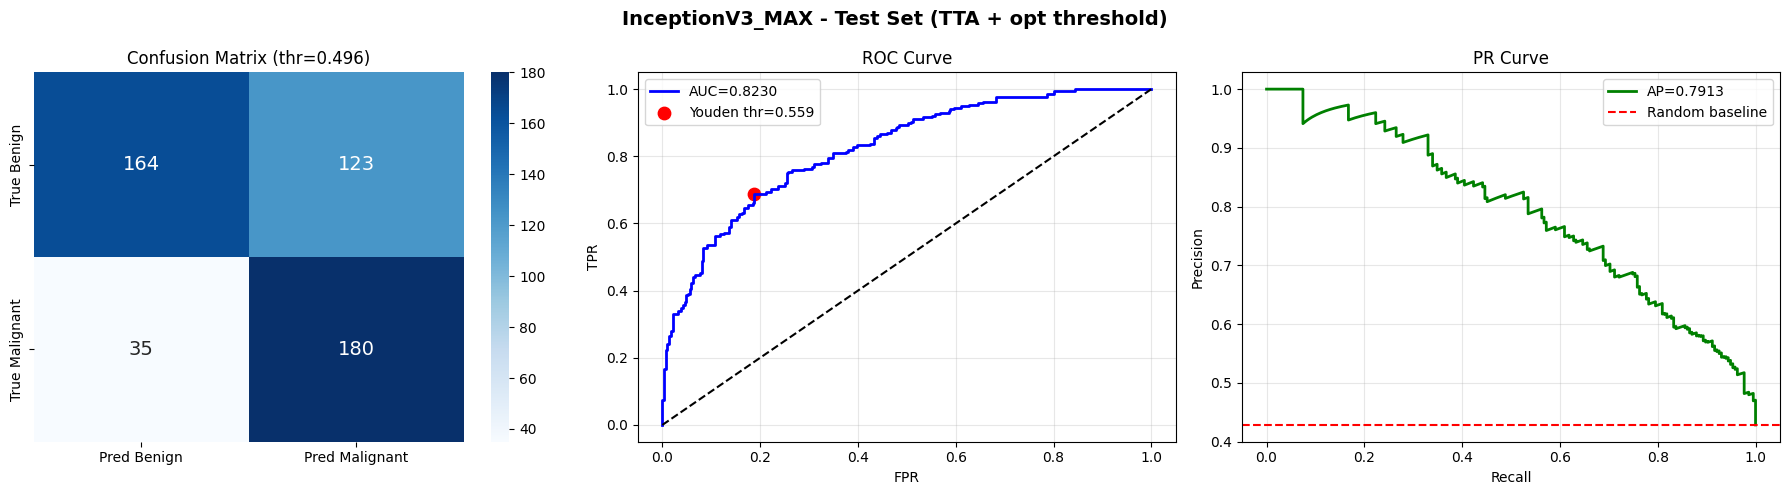

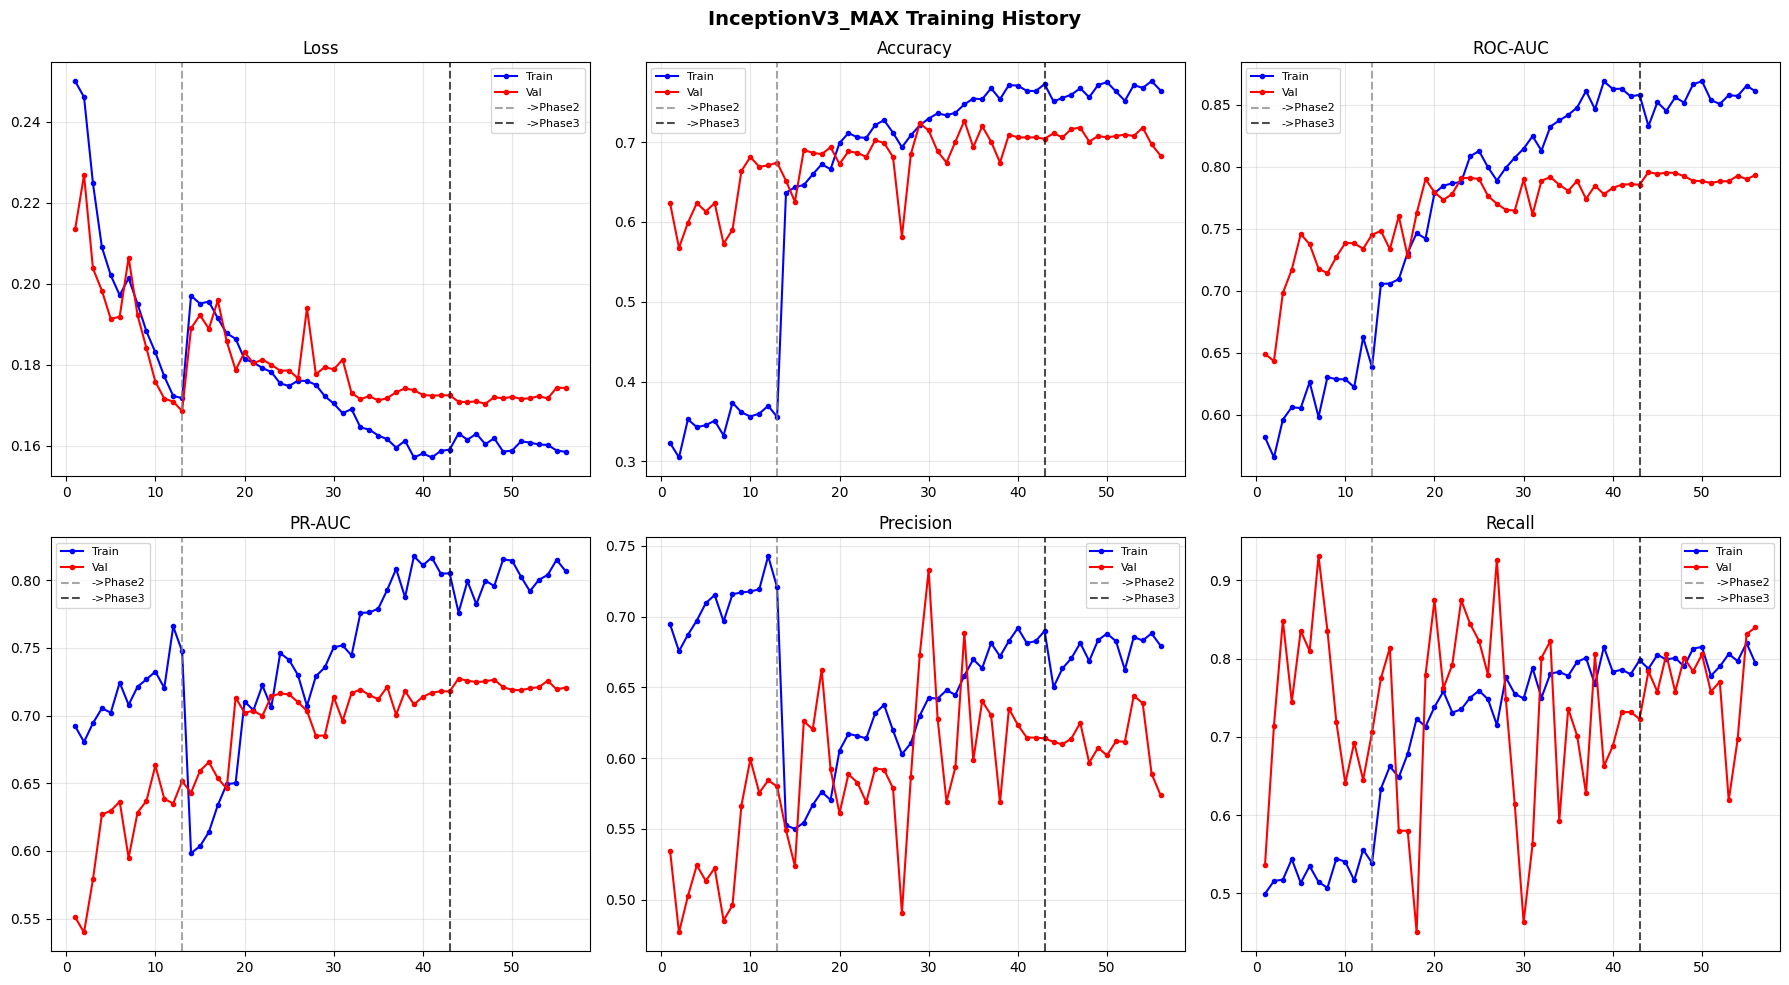

In [14]:
# ============================================================================
# CELL 14 - Plots: confusion matrix, ROC, PR, training history
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_NAME} - Test Set (TTA + opt threshold)', fontsize=14, fontweight='bold')

sns.heatmap(m_opt['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Benign', 'Pred Malignant'],
            yticklabels=['True Benign', 'True Malignant'], annot_kws={'size': 14})
axes[0].set_title(f'Confusion Matrix (thr={OPT_THR:.3f})')

axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc_roc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
youden_idx = np.argmax(tpr - fpr)
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', s=80,
                label=f"Youden thr={thr_arr[youden_idx]:.3f}")
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

pr_p, pr_r, _ = precision_recall_curve(y_true_test, y_prob_test)
axes[2].plot(pr_r, pr_p, 'g-', lw=2, label=f'AP={ap:.4f}')
axes[2].axhline(y_true_test.mean(), color='r', ls='--', label='Random baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].set_title('PR Curve')
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ----- Training-history plot ---------------------------------------------
def safe_get(h, key):
    return h.history.get(key, [np.nan] * len(h.history.get('loss', [])))

all_hist = {
    k: safe_get(history_p1, k) + safe_get(history_p2, k) + safe_get(history_p3, k)
    for k in ['loss', 'val_loss', 'accuracy', 'val_accuracy',
              'auc', 'val_auc', 'pr_auc', 'val_pr_auc',
              'precision', 'val_precision', 'recall', 'val_recall']
}
p1_end = len(history_p1.history['loss'])
p2_end = p1_end + len(history_p2.history['loss'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'{MODEL_NAME} Training History', fontsize=14, fontweight='bold')
for ax, (tk, vk, title) in zip(axes.flat, [
    ('loss',      'val_loss',      'Loss'),
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('auc',       'val_auc',       'ROC-AUC'),
    ('pr_auc',    'val_pr_auc',    'PR-AUC'),
    ('precision', 'val_precision', 'Precision'),
    ('recall',    'val_recall',    'Recall'),
]):
    ep = range(1, len(all_hist[tk]) + 1)
    ax.plot(ep, all_hist[tk], 'b-o', ms=3, label='Train')
    ax.plot(ep, all_hist[vk], 'r-o', ms=3, label='Val')
    ax.axvline(p1_end, color='gray',  ls='--', alpha=0.7, label='->Phase2')
    ax.axvline(p2_end, color='black', ls='--', alpha=0.7, label='->Phase3')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================================
# CELL 15 - Save final results + comparison vs previous baseline
# ============================================================================
BASELINE = {
    'accuracy': 0.6594, 'auc_roc': 0.7811, 'f1': 0.6680,
    'sensitivity': 0.8000, 'specificity': 0.5540,
    'TP': 172, 'TN': 159, 'FP': 128, 'FN': 43,
}

results = {
    'model'        : 'inceptionv3_max_power',
    'img_size'     : IMG_SIZE,
    'opt_threshold': round(OPT_THR, 4),
    'tta_steps'    : TTA_STEPS,
    'use_ensemble' : USE_ENSEMBLE,
    'accuracy'     : round(m_opt['acc'],  4),
    'bal_accuracy' : round(m_opt['bacc'], 4),
    'auc_roc'      : round(auc_roc,        4),
    'pr_auc'       : round(ap,             4),
    'f1'           : round(m_opt['f1'],   4),
    'mcc'          : round(m_opt['mcc'],  4),
    'sensitivity'  : round(m_opt['sens'], 4),
    'specificity'  : round(m_opt['spec'], 4),
    'precision'    : round(m_opt['prec'], 4),
    'npv'          : round(m_opt['npv'],  4),
    'TP': m_opt['tp'], 'TN': m_opt['tn'], 'FP': m_opt['fp'], 'FN': m_opt['fn'],
    'miss_rate'    : round(m_opt['fn'] / (m_opt['fn'] + m_opt['tp']), 4),
}

pd.DataFrame([results]).to_csv(SAVE_DIR / 'results_summary.csv', index=False)

master_csv = SAVE_DIR.parent / 'all_models_comparison.csv'
df_master = pd.read_csv(master_csv) if master_csv.exists() else pd.DataFrame()
if len(df_master):
    df_master = df_master[df_master['model'] != 'inceptionv3_max_power']
df_master = pd.concat([df_master, pd.DataFrame([results])], ignore_index=True)
df_master.to_csv(master_csv, index=False)

print('\n' + '='*70)
print('  IMPROVEMENT vs BASELINE InceptionV3')
print('='*70)
for k in ['accuracy', 'auc_roc', 'f1', 'sensitivity', 'specificity']:
    base_v = BASELINE[k]
    new_v  = results[k]
    diff   = new_v - base_v
    arrow  = ' UP ' if diff > 0 else 'DOWN' if diff < 0 else 'SAME'
    pct    = (diff / base_v * 100) if base_v > 0 else 0
    print(f'  {k:<13}: {base_v:.4f}  ->  {new_v:.4f}  ({arrow} {diff:+.4f}, {pct:+.2f}%)')

print('\n' + '='*70)
print(f'  FINAL: AUC={auc_roc:.4f}  Acc={m_opt["acc"]:.4f}  F1={m_opt["f1"]:.4f}')
print(f'         Sens={m_opt["sens"]:.4f}  Spec={m_opt["spec"]:.4f}  MCC={m_opt["mcc"]:.4f}')
print('='*70)
print(f'\n  All artefacts saved under: {SAVE_DIR}')


  IMPROVEMENT vs BASELINE InceptionV3
  accuracy     : 0.6594  ->  0.6853  ( UP  +0.0259, +3.93%)
  auc_roc      : 0.7811  ->  0.8230  ( UP  +0.0419, +5.36%)
  f1           : 0.6680  ->  0.6950  ( UP  +0.0270, +4.04%)
  sensitivity  : 0.8000  ->  0.8372  ( UP  +0.0372, +4.65%)
  specificity  : 0.5540  ->  0.5714  ( UP  +0.0174, +3.14%)

  FINAL: AUC=0.8230  Acc=0.6853  F1=0.6950
         Sens=0.8372  Spec=0.5714  MCC=0.4134

  All artefacts saved under: /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power


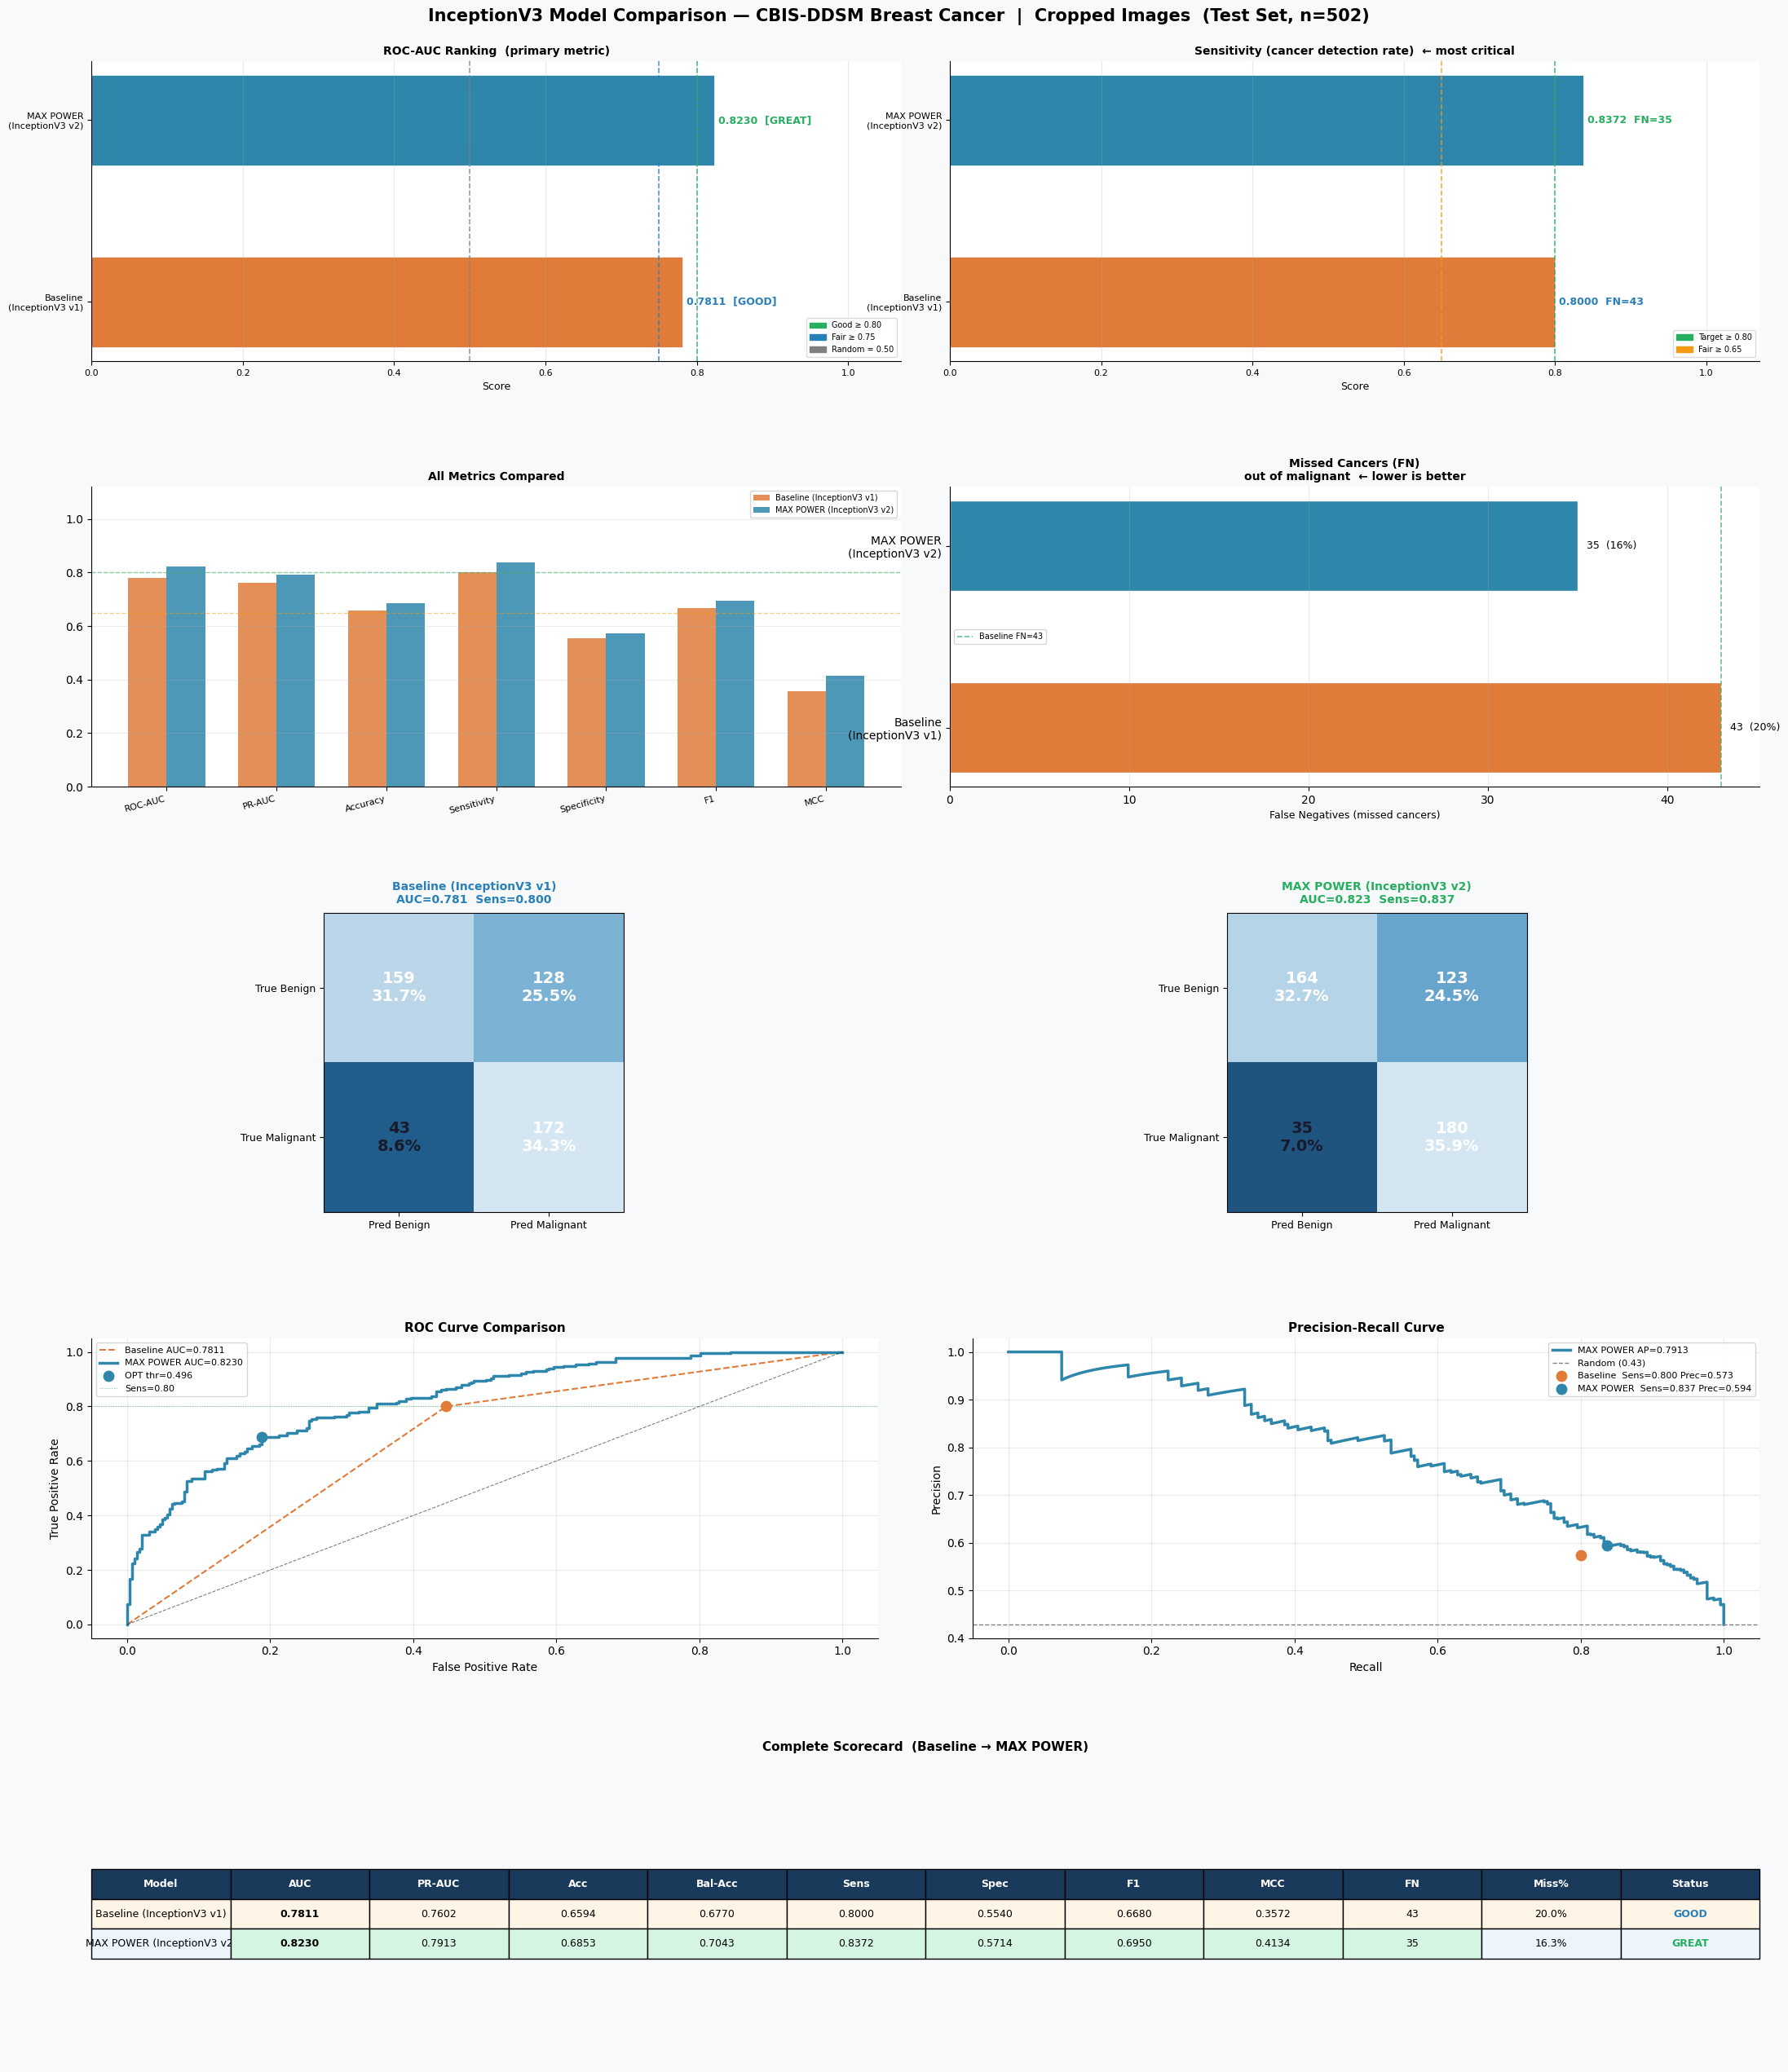

  Dashboard saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/inceptionv3_max_power/model_comparison_dashboard.png


In [16]:
# ============================================================================
# CELL 16 - Comprehensive Dashboard  (mirrors the 6-model comparison image)
#            Paste this cell after CELL 13 has run.  No extra imports needed.
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

# ── helpers ─────────────────────────────────────────────────────────────────
def status_color(auc):
    if auc >= 0.80: return '#27AE60'
    if auc >= 0.75: return '#2980B9'
    if auc >= 0.65: return '#F39C12'
    return '#E74C3C'

def status_label(auc):
    if auc >= 0.80: return 'GREAT'
    if auc >= 0.75: return 'GOOD'
    if auc >= 0.65: return 'FAIR'
    return 'FAILED'

# ── Model registry (Baseline hard-coded, MAX POWER read from live variables) -
_b_tp, _b_tn, _b_fp, _b_fn = 172, 159, 128, 43
MODELS = {
    'Baseline\n(InceptionV3 v1)': dict(
        color='#E07B39',
        auc=0.7811, pr_auc=0.7602,
        acc=0.6594, sens=0.8000, spec=0.5540,
        prec=_b_tp/(_b_tp+_b_fp),          # 0.5733
        f1=0.6680,  mcc=0.3572,
        fn=_b_fn,   tp=_b_tp, tn=_b_tn, fp=_b_fp,
        n_mal=_b_tp+_b_fn,
    ),
    'MAX POWER\n(InceptionV3 v2)': dict(
        color='#2E86AB',
        auc=auc_roc, pr_auc=ap,
        acc=m_opt['acc'], sens=m_opt['sens'], spec=m_opt['spec'],
        prec=m_opt['prec'],
        f1=m_opt['f1'], mcc=m_opt['mcc'],
        fn=m_opt['fn'], tp=m_opt['tp'], tn=m_opt['tn'], fp=m_opt['fp'],
        n_mal=m_opt['tp']+m_opt['fn'],
    ),
}

names  = list(MODELS.keys())
colors = [v['color'] for v in MODELS.values()]
n_test_total = m_opt['tp'] + m_opt['tn'] + m_opt['fp'] + m_opt['fn']

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor='#F8F9FA')
fig.suptitle(
    f'InceptionV3 Model Comparison — CBIS-DDSM Breast Cancer  |  Cropped Images'
    f'  (Test Set, n={n_test_total})',
    fontsize=15, fontweight='bold', y=0.99)

outer = gridspec.GridSpec(5, 1, figure=fig, hspace=0.42,
                          top=0.965, bottom=0.02, left=0.05, right=0.98)

# ── ROW 0 : AUC bar  |  Sensitivity bar ─────────────────────────────────────
row0   = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.06)
ax_auc  = fig.add_subplot(row0[0])
ax_sens = fig.add_subplot(row0[1])

for ax, metric, title, reflines in [
    (ax_auc,  'auc',  'ROC-AUC Ranking  (primary metric)',
     [(0.80,'#27AE60','Good ≥ 0.80'), (0.75,'#2980B9','Fair ≥ 0.75'), (0.50,'gray','Random = 0.50')]),
    (ax_sens, 'sens', 'Sensitivity (cancer detection rate)  ← most critical',
     [(0.80,'#27AE60','Target ≥ 0.80'), (0.65,'#F39C12','Fair ≥ 0.65')]),
]:
    vals = [MODELS[n][metric] for n in names]
    bars = ax.barh(names, vals, color=colors, height=0.5, edgecolor='white', linewidth=0.5)
    for bar, val, nm in zip(bars, vals, names):
        sc  = status_color(MODELS[nm]['auc'])
        lbl = (f'{val:.4f}  [{status_label(MODELS[nm]["auc"])}]' if metric == 'auc'
               else f'{val:.4f}  FN={MODELS[nm]["fn"]}')
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                lbl, va='center', fontsize=9, color=sc, fontweight='bold')
    for xv, c, lbl in reflines:
        ax.axvline(xv, color=c, ls='--', lw=1.2, alpha=0.8)
    ax.set_xlim(0, 1.07)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('Score', fontsize=9)
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    handles = [mpatches.Patch(color=c, label=lbl) for _, c, lbl in reflines]
    ax.legend(handles=handles, fontsize=7, loc='lower right', framealpha=0.7)

# ── ROW 1 : All metrics grouped bar  |  Missed-cancers FN bar ───────────────
row1     = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.06)
ax_multi = fig.add_subplot(row1[0])
ax_fn    = fig.add_subplot(row1[1])

MK   = ['auc', 'pr_auc', 'acc', 'sens', 'spec', 'f1', 'mcc']
MLBL = ['ROC-AUC', 'PR-AUC', 'Accuracy', 'Sensitivity', 'Specificity', 'F1', 'MCC']
x  = np.arange(len(MK))
bw = 0.35
for i, (nm, col) in enumerate(zip(names, colors)):
    vals = [max(MODELS[nm][k], 0) for k in MK]
    ax_multi.bar(x + (i - 0.5)*bw, vals, bw, color=col, alpha=0.85,
                 label=nm.replace('\n', ' '))
ax_multi.set_xticks(x)
ax_multi.set_xticklabels(MLBL, rotation=15, ha='right', fontsize=8)
ax_multi.set_ylim(0, 1.12)
ax_multi.set_title('All Metrics Compared', fontsize=10, fontweight='bold')
ax_multi.legend(fontsize=7, loc='upper right')
ax_multi.grid(axis='y', alpha=0.25)
ax_multi.spines[['top', 'right']].set_visible(False)
ax_multi.axhline(0.80, color='#27AE60', ls='--', lw=1, alpha=0.5)
ax_multi.axhline(0.65, color='#F39C12', ls='--', lw=1, alpha=0.5)

fn_vals = [MODELS[n]['fn']    for n in names]
n_mals  = [MODELS[n]['n_mal'] for n in names]
fn_bars = ax_fn.barh(names, fn_vals, color=colors, height=0.5, edgecolor='white')
for bar, fn, n_mal in zip(fn_bars, fn_vals, n_mals):
    ax_fn.text(fn + 0.5, bar.get_y() + bar.get_height()/2,
               f'{fn}  ({fn/n_mal*100:.0f}%)', va='center', fontsize=9)
ax_fn.axvline(43, color='#27AE60', ls='--', lw=1.2, alpha=0.7, label='Baseline FN=43')
ax_fn.set_title('Missed Cancers (FN)\nout of malignant  ← lower is better',
                fontsize=10, fontweight='bold')
ax_fn.set_xlabel('False Negatives (missed cancers)', fontsize=9)
ax_fn.legend(fontsize=7)
ax_fn.grid(axis='x', alpha=0.25)
ax_fn.spines[['top', 'right']].set_visible(False)

# ── ROW 2 : Confusion matrices ───────────────────────────────────────────────
row2   = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.18)
cmap_cm = LinearSegmentedColormap.from_list('cm', ['#1A3A5C', '#2980B9', '#D4E6F1'])
for i, nm in enumerate(names):
    d   = MODELS[nm]
    cm_arr = np.array([[d['tn'], d['fp']], [d['fn'], d['tp']]])
    n   = cm_arr.sum()
    ax  = fig.add_subplot(row2[i])
    ax.imshow(cm_arr, cmap=cmap_cm, vmin=0, vmax=cm_arr.max())
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm_arr[r,c]}\n{cm_arr[r,c]/n*100:.1f}%',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm_arr[r,c] > cm_arr.max()*0.4 else '#1A1A2E')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Malignant'], fontsize=9)
    ax.set_yticklabels(['True Benign', 'True Malignant'], fontsize=9)
    ax.set_title(
        f'{nm.replace(chr(10)," ")}\nAUC={d["auc"]:.3f}  Sens={d["sens"]:.3f}',
        fontsize=10, fontweight='bold', color=status_color(d['auc']), pad=8)

# ── ROW 3 : ROC curve  |  PR curve ───────────────────────────────────────────
row3   = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.12)
ax_roc = fig.add_subplot(row3[0])
ax_pr  = fig.add_subplot(row3[1])

fpr_n, tpr_n, thr_n = roc_curve(y_true_test, y_prob_test)
yi = np.argmax(tpr_n - fpr_n)

b = MODELS['Baseline\n(InceptionV3 v1)']
ax_roc.plot([0, 1-b['spec'], 1], [0, b['sens'], 1],
            '--', color=colors[0], lw=1.5, label=f'Baseline AUC={b["auc"]:.4f}')
ax_roc.plot(fpr_n, tpr_n, '-', color=colors[1], lw=2.5,
            label=f'MAX POWER AUC={auc_roc:.4f}')
ax_roc.scatter([1-b['spec']], [b['sens']], color=colors[0], s=80, zorder=5)
ax_roc.scatter([fpr_n[yi]], [tpr_n[yi]], color=colors[1], s=80, zorder=5,
               label=f'OPT thr={OPT_THR:.3f}')
ax_roc.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.5)
ax_roc.axhline(0.80, color='#27AE60', ls=':', lw=0.8, alpha=0.6, label='Sens=0.80')
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison', fontsize=11, fontweight='bold')
ax_roc.legend(fontsize=8); ax_roc.grid(alpha=0.25)
ax_roc.spines[['top','right']].set_visible(False)

pr_p, pr_r, _ = precision_recall_curve(y_true_test, y_prob_test)
bfrac = y_true_test.mean()
ax_pr.plot(pr_r, pr_p, '-', color=colors[1], lw=2.5, label=f'MAX POWER AP={ap:.4f}')
ax_pr.axhline(bfrac, color='gray', ls='--', lw=1, label=f'Random ({bfrac:.2f})')
ax_pr.scatter([b['sens']], [b['prec']], color=colors[0], s=80, zorder=5,
              label=f'Baseline  Sens={b["sens"]:.3f} Prec={b["prec"]:.3f}')
ax_pr.scatter([m_opt['sens']], [m_opt['prec']], color=colors[1], s=80, zorder=5,
              label=f'MAX POWER  Sens={m_opt["sens"]:.3f} Prec={m_opt["prec"]:.3f}')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontsize=11, fontweight='bold')
ax_pr.legend(fontsize=8); ax_pr.grid(alpha=0.25)
ax_pr.spines[['top','right']].set_visible(False)

# ── ROW 4 : Complete Scorecard table ─────────────────────────────────────────
ax_tbl = fig.add_subplot(outer[4])
ax_tbl.axis('off')

COLS      = ['Model','AUC','PR-AUC','Acc','Bal-Acc','Sens','Spec','F1','MCC','FN','Miss%','Status']
rows_data = []
for nm in names:
    d  = MODELS[nm]
    ba = (d['sens'] + d['spec']) / 2
    rows_data.append([
        nm.replace('\n', ' '),
        f'{d["auc"]:.4f}', f'{d["pr_auc"]:.4f}',
        f'{d["acc"]:.4f}', f'{ba:.4f}',
        f'{d["sens"]:.4f}', f'{d["spec"]:.4f}',
        f'{d["f1"]:.4f}',  f'{d["mcc"]:.4f}',
        str(d['fn']),
        f'{d["fn"]/d["n_mal"]*100:.1f}%',
        status_label(d['auc']),
    ])

tbl = ax_tbl.table(cellText=rows_data, colLabels=COLS, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.2)

for j in range(len(COLS)):
    tbl[(0, j)].set_facecolor('#1A3A5C')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

row_bg = ['#FEF5E7', '#EBF5FB']
for i, nm in enumerate(names):
    sc = status_color(MODELS[nm]['auc'])
    for j in range(len(COLS)):
        cell = tbl[(i+1, j)]
        cell.set_facecolor(row_bg[i])
        if j == len(COLS)-1:
            cell.set_text_props(color=sc, fontweight='bold')
        if j == 1:
            cell.set_text_props(fontweight='bold')

# Highlight the better value in each metric column (green cell)
metric_col_higher_is_better = {1, 2, 3, 4, 5, 6, 7, 8}  # all except FN(9)/Miss%(10)
for col_idx in range(1, len(COLS)-2):
    try:
        raw   = [tbl[(r+1, col_idx)].get_text().get_text().replace('%','')
                 for r in range(len(names))]
        vals  = [float(v) for v in raw]
        best  = max(vals) if col_idx in metric_col_higher_is_better else min(vals)
        for r, v in enumerate(vals):
            if abs(v - best) < 1e-6:
                tbl[(r+1, col_idx)].set_facecolor('#D5F5E3')
    except Exception:
        pass

ax_tbl.set_title('Complete Scorecard  (Baseline → MAX POWER)',
                 fontsize=11, fontweight='bold', pad=12, y=1.0)

plt.savefig(SAVE_DIR / 'model_comparison_dashboard.png',
            dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print(f'  Dashboard saved → {SAVE_DIR}/model_comparison_dashboard.png')
